# EEG Oddball Classification: Model Training and Evaluation

## Objective
This notebook implements and evaluates machine learning models for binary classification of EEG oddball paradigm trials (Frequent vs Target stimuli).

## Methodology
- **Dataset**: Aggregated data from 5 subjects (sub-01 through sub-05)
- **Design**: Balanced (50/50) using undersampling of frequent trials
- **Models**: Support Vector Machine (SVM), Random Forest (RF), Multi-Layer Perceptron (MLP)
- **Features**: EEG band power & ERP components (28 features) vs HMM state occupancy (8 features)
- **Evaluation**: Accuracy, Precision, Recall, F1-Score, ROC-AUC with 5-fold cross-validation

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Configuration

In [2]:
# Directories
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

INPUT_FILES = {
    "EEG": "../data/eeg.csv",
    "HMM": "../data/hmm.csv"
}

# Column definitions
SUBJECT_COL = 'subject_id'
LABEL_COL = 'label'
EPOCH_ID_COL = 'epoch_id'

# Stimulus labels
FREQUENT_LABEL = 'Stimulus/S  5'
TARGET_LABEL = 'Stimulus/S  6'

# Reproducibility
RANDOM_STATE = 42

print(f"Configuration loaded.")
print(f"Frequent stimulus: {FREQUENT_LABEL}")
print(f"Target stimulus: {TARGET_LABEL}")

Configuration loaded.
Frequent stimulus: Stimulus/S  5
Target stimulus: Stimulus/S  6


## 3. Data Loading and Balancing

Aggregate all subjects and apply random undersampling to frequent trials to achieve class balance.

In [3]:
def load_and_balance_all_subjects(filepath):
    """
    Load data from all subjects and create balanced dataset via undersampling.
    
    Returns:
        X: Feature matrix
        y: Binary labels (0=Frequent, 1=Target)
        info: Dataset statistics
    """
    print("\n" + "="*70)
    print("DATA LOADING AND BALANCING")
    print("="*70)
    
    df = pd.read_csv(filepath)
    df_filtered = df[df[LABEL_COL].isin([FREQUENT_LABEL, TARGET_LABEL])].copy()
    
    # Display per-subject distribution
    print("\nOriginal distribution per subject:")
    subjects = sorted(df_filtered[SUBJECT_COL].unique())
    
    for subject in subjects:
        df_subj = df_filtered[df_filtered[SUBJECT_COL] == subject]
        freq_count = (df_subj[LABEL_COL] == FREQUENT_LABEL).sum()
        targ_count = (df_subj[LABEL_COL] == TARGET_LABEL).sum()
        print(f"  {subject}: Frequent={freq_count:3d}, Target={targ_count:3d}")
    
    # Aggregate statistics
    total_frequent = (df_filtered[LABEL_COL] == FREQUENT_LABEL).sum()
    total_target = (df_filtered[LABEL_COL] == TARGET_LABEL).sum()
    
    print(f"\nAggregated totals:")
    print(f"  Frequent: {total_frequent}")
    print(f"  Target:   {total_target}")
    print(f"  Ratio:    {total_frequent/total_target:.1f}:1")
    
    # Apply undersampling
    df_frequent = df_filtered[df_filtered[LABEL_COL] == FREQUENT_LABEL]
    df_target = df_filtered[df_filtered[LABEL_COL] == TARGET_LABEL]
    
    n_target = len(df_target)
    df_frequent_sampled = df_frequent.sample(n=n_target, random_state=RANDOM_STATE)
    
    df_balanced = pd.concat([df_frequent_sampled, df_target], axis=0)
    df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    
    print(f"\nBalanced dataset:")
    print(f"  Frequent: {n_target}")
    print(f"  Target:   {n_target}")
    print(f"  Total:    {len(df_balanced)} samples (50/50 split)")
    
    # Extract features and labels
    X = df_balanced.drop(columns=[LABEL_COL, SUBJECT_COL, EPOCH_ID_COL])
    y = (df_balanced[LABEL_COL] == TARGET_LABEL).astype(int)
    
    info = {
        'n_subjects': len(subjects),
        'subjects': subjects,
        'original_frequent': total_frequent,
        'original_target': total_target,
        'balanced_each': n_target,
        'total_samples': len(df_balanced),
        'n_features': X.shape[1]
    }
    
    print(f"  Features: {info['n_features']}")
    print("="*70 + "\n")
    
    return X, y, info

## 4. Model Training with Hyperparameter Optimization

In [4]:
def train_model(X_train, X_test, y_train, y_test, model_type, model_name):
    """
    Train model with grid search and compute performance metrics.
    """
    print(f"  Training {model_name}...", end=' ')
    
    # Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Model initialization and hyperparameter grids
    if model_type == 'svm':
        model = SVC(probability=True, random_state=RANDOM_STATE)
        param_grid = {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto'],
            'kernel': ['rbf']
        }
    
    elif model_type == 'rf':
        model = RandomForestClassifier(random_state=RANDOM_STATE)
        param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5, 10]
        }
    
    elif model_type == 'nn':
        model = MLPClassifier(random_state=RANDOM_STATE, max_iter=2000, early_stopping=True)
        param_grid = {
            'hidden_layer_sizes': [(64, 32), (128, 64), (100,)],
            'alpha': [0.0001, 0.001, 0.01],
            'learning_rate_init': [0.001, 0.01]
        }
    
    # Grid search with stratified k-fold cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    grid_search = GridSearchCV(
        model, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=0
    )
    
    grid_search.fit(X_train_scaled, y_train)
    best_model = grid_search.best_estimator_
    
    # Predictions
    y_pred = best_model.predict(X_test_scaled)
    y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    
    # Compute metrics
    metrics = {
        'model_name': model_name,
        'best_params': grid_search.best_params_,
        'cv_f1': grid_search.best_score_,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'model': best_model,
        'scaler': scaler
    }
    
    print(f"F1={metrics['f1']:.3f}, AUC={metrics['roc_auc']:.3f}")
    
    return metrics

In [5]:
def train_all_models(X, y, feature_name):
    """
    Train all three models and return comprehensive results.
    """
    print("\n" + "="*70)
    print(f"MODEL TRAINING: {feature_name} Features")
    print("="*70)
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    
    print(f"\nDataset split:")
    print(f"  Train: {len(X_train)} samples")
    print(f"  Test:  {len(X_test)} samples\n")
    
    # Train models
    models_config = [
        ('svm', 'SVM'),
        ('rf', 'Random Forest'),
        ('nn', 'Neural Network')
    ]
    
    results = {}
    for model_type, model_name in models_config:
        try:
            result = train_model(X_train, X_test, y_train, y_test, model_type, model_name)
            results[model_type] = result
        except Exception as e:
            print(f"  Error: {e}")
            results[model_type] = None
    
    print("\n" + "="*70 + "\n")
    
    return results

## 5. EEG Features: Data Loading and Model Training

In [6]:
X_eeg, y_eeg, info_eeg = load_and_balance_all_subjects(INPUT_FILES['EEG'])
results_eeg = train_all_models(X_eeg, y_eeg, 'EEG')


DATA LOADING AND BALANCING

Original distribution per subject:
  sub-01: Frequent= 67, Target=  5
  sub-02: Frequent= 32, Target= 11
  sub-03: Frequent=295, Target= 77
  sub-04: Frequent= 53, Target=  1
  sub-05: Frequent=348, Target= 12

Aggregated totals:
  Frequent: 795
  Target:   106
  Ratio:    7.5:1

Balanced dataset:
  Frequent: 106
  Target:   106
  Total:    212 samples (50/50 split)
  Features: 28


MODEL TRAINING: EEG Features

Dataset split:
  Train: 169 samples
  Test:  43 samples

  Training SVM... F1=0.656, AUC=0.394
  Training Random Forest... F1=0.634, AUC=0.728
  Training Neural Network... F1=0.550, AUC=0.613




## 6. HMM Features: Data Loading and Model Training

In [7]:
X_hmm, y_hmm, info_hmm = load_and_balance_all_subjects(INPUT_FILES['HMM'])
results_hmm = train_all_models(X_hmm, y_hmm, 'HMM')


DATA LOADING AND BALANCING

Original distribution per subject:
  sub-01: Frequent= 67, Target=  5
  sub-02: Frequent= 32, Target= 11
  sub-03: Frequent=295, Target= 77
  sub-04: Frequent= 53, Target=  1
  sub-05: Frequent=348, Target= 12

Aggregated totals:
  Frequent: 795
  Target:   106
  Ratio:    7.5:1

Balanced dataset:
  Frequent: 106
  Target:   106
  Total:    212 samples (50/50 split)
  Features: 8


MODEL TRAINING: HMM Features

Dataset split:
  Train: 169 samples
  Test:  43 samples

  Training SVM... F1=0.800, AUC=0.861
  Training Random Forest... F1=0.703, AUC=0.866
  Training Neural Network... F1=0.816, AUC=0.859




## 7. Performance Summary

In [8]:
# Create summary table
summary_data = []

for feature_type, results in [('EEG', results_eeg), ('HMM', results_hmm)]:
    for model_key in ['svm', 'rf', 'nn']:
        if results[model_key] is not None:
            r = results[model_key]
            summary_data.append({
                'Feature': feature_type,
                'Model': r['model_name'],
                'CV_F1': r['cv_f1'],
                'Test_Accuracy': r['accuracy'],
                'Test_Precision': r['precision'],
                'Test_Recall': r['recall'],
                'Test_F1': r['f1'],
                'Test_ROC_AUC': r['roc_auc']
            })

df_summary = pd.DataFrame(summary_data)

print("\n" + "="*100)
print("PERFORMANCE SUMMARY")
print("="*100)
print(df_summary.to_string(index=False))
print("="*100)

# Save results
summary_path = os.path.join(RESULTS_DIR, 'model_performance_summary.csv')
df_summary.to_csv(summary_path, index=False)
print(f"\nResults saved: {summary_path}")


PERFORMANCE SUMMARY
Feature          Model    CV_F1  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_ROC_AUC
    EEG            SVM 0.645833       0.488372        0.488372     1.000000 0.656250      0.393939
    EEG  Random Forest 0.583929       0.651163        0.650000     0.619048 0.634146      0.728355
    EEG Neural Network 0.606667       0.581395        0.578947     0.523810 0.550000      0.612554
    HMM            SVM 0.751527       0.790698        0.750000     0.857143 0.800000      0.861472
    HMM  Random Forest 0.724224       0.744186        0.812500     0.619048 0.702703      0.865801
    HMM Neural Network 0.767095       0.790698        0.714286     0.952381 0.816327      0.859307

Results saved: ../results\model_performance_summary.csv


## 8. Visualization

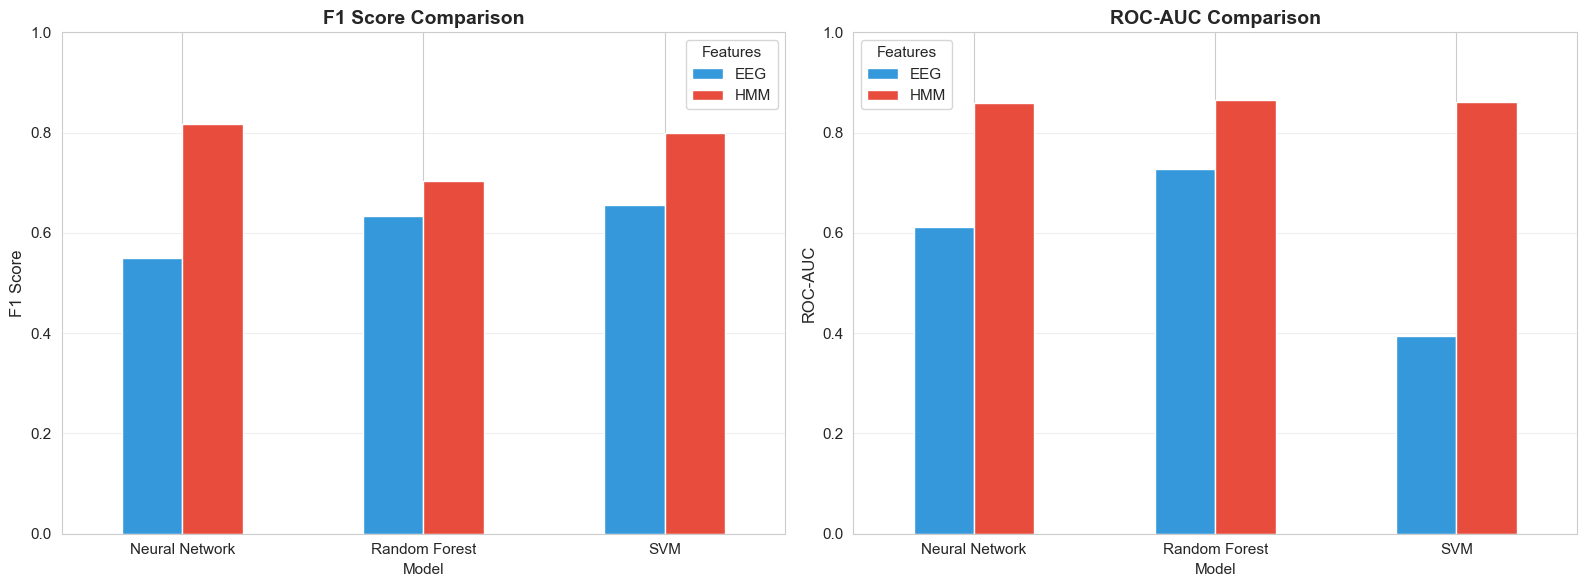

Saved: performance_comparison.png


In [9]:
# Performance comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_f1 = df_summary.pivot(index='Model', columns='Feature', values='Test_F1')
df_f1.plot(kind='bar', ax=axes[0], rot=0, color=['#3498db', '#e74c3c'])
axes[0].set_title('F1 Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('F1 Score', fontsize=12)
axes[0].set_ylim(0, 1.0)
axes[0].legend(title='Features')
axes[0].grid(axis='y', alpha=0.3)

df_auc = df_summary.pivot(index='Model', columns='Feature', values='Test_ROC_AUC')
df_auc.plot(kind='bar', ax=axes[1], rot=0, color=['#3498db', '#e74c3c'])
axes[1].set_title('ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('ROC-AUC', fontsize=12)
axes[1].set_ylim(0, 1.0)
axes[1].legend(title='Features')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'performance_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Saved: performance_comparison.png")

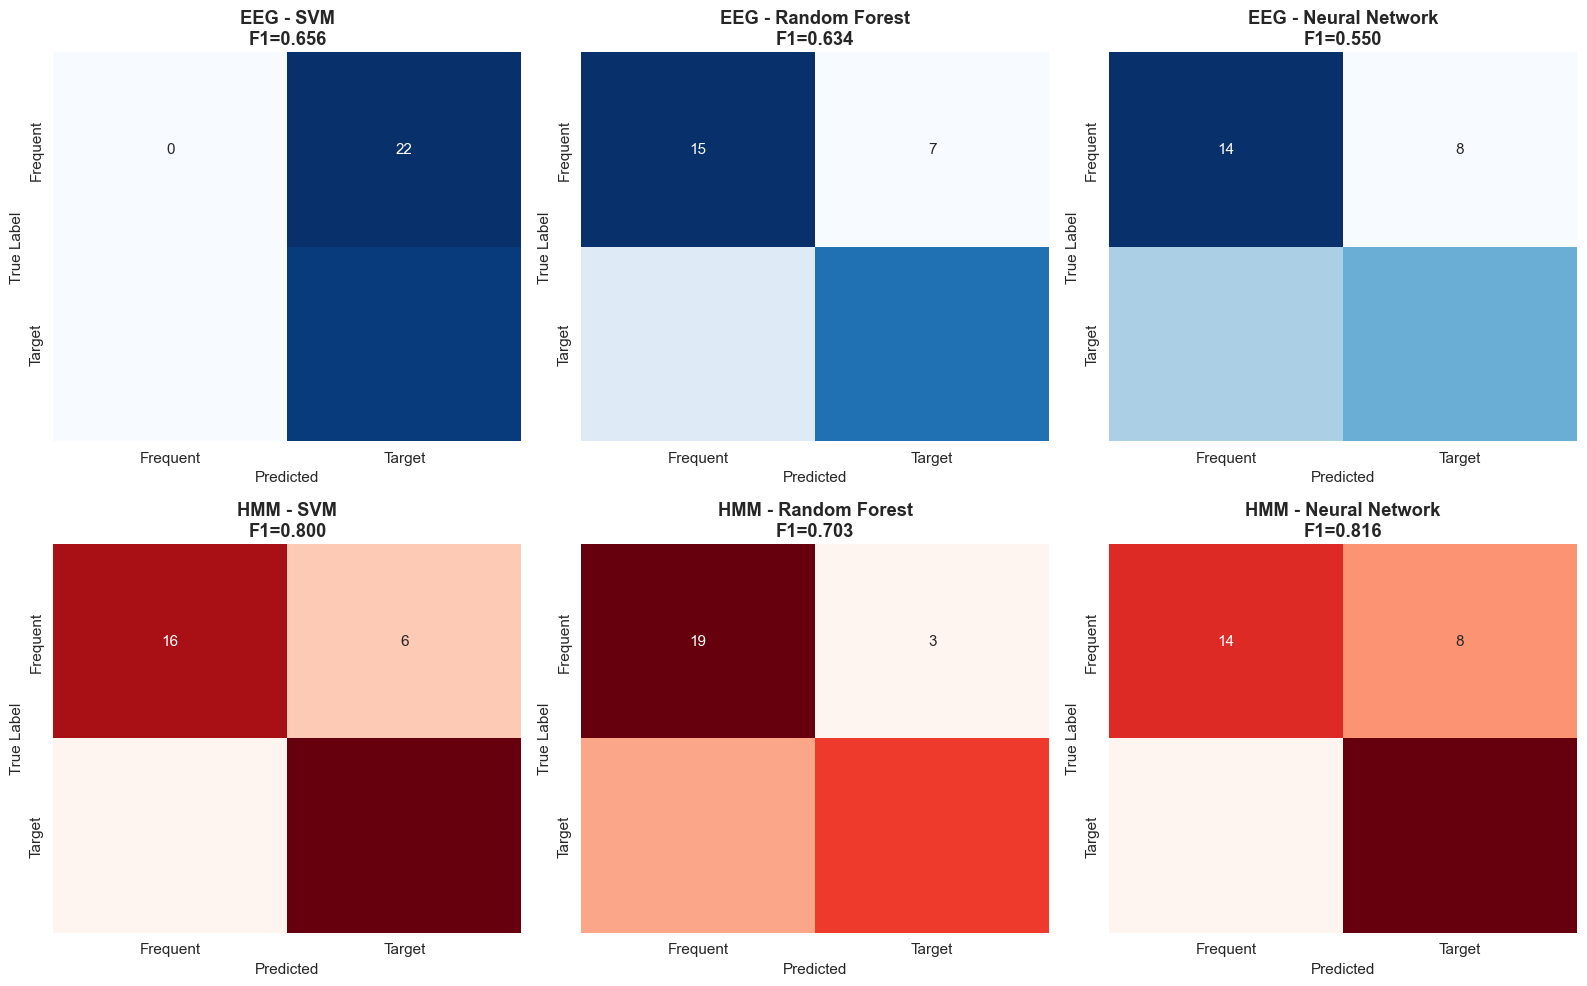

Saved: confusion_matrices.png


In [10]:
# Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

model_names = ['SVM', 'Random Forest', 'Neural Network']
model_keys = ['svm', 'rf', 'nn']

for idx, (key, name) in enumerate(zip(model_keys, model_names)):
    if results_eeg[key] is not None:
        cm = results_eeg[key]['confusion_matrix']
        f1 = results_eeg[key]['f1']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, idx],
                    xticklabels=['Frequent', 'Target'],
                    yticklabels=['Frequent', 'Target'], cbar=False)
        axes[0, idx].set_title(f'EEG - {name}\nF1={f1:.3f}', fontweight='bold')
        axes[0, idx].set_ylabel('True Label')
        axes[0, idx].set_xlabel('Predicted')

for idx, (key, name) in enumerate(zip(model_keys, model_names)):
    if results_hmm[key] is not None:
        cm = results_hmm[key]['confusion_matrix']
        f1 = results_hmm[key]['f1']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[1, idx],
                    xticklabels=['Frequent', 'Target'],
                    yticklabels=['Frequent', 'Target'], cbar=False)
        axes[1, idx].set_title(f'HMM - {name}\nF1={f1:.3f}', fontweight='bold')
        axes[1, idx].set_ylabel('True Label')
        axes[1, idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrices.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Saved: confusion_matrices.png")

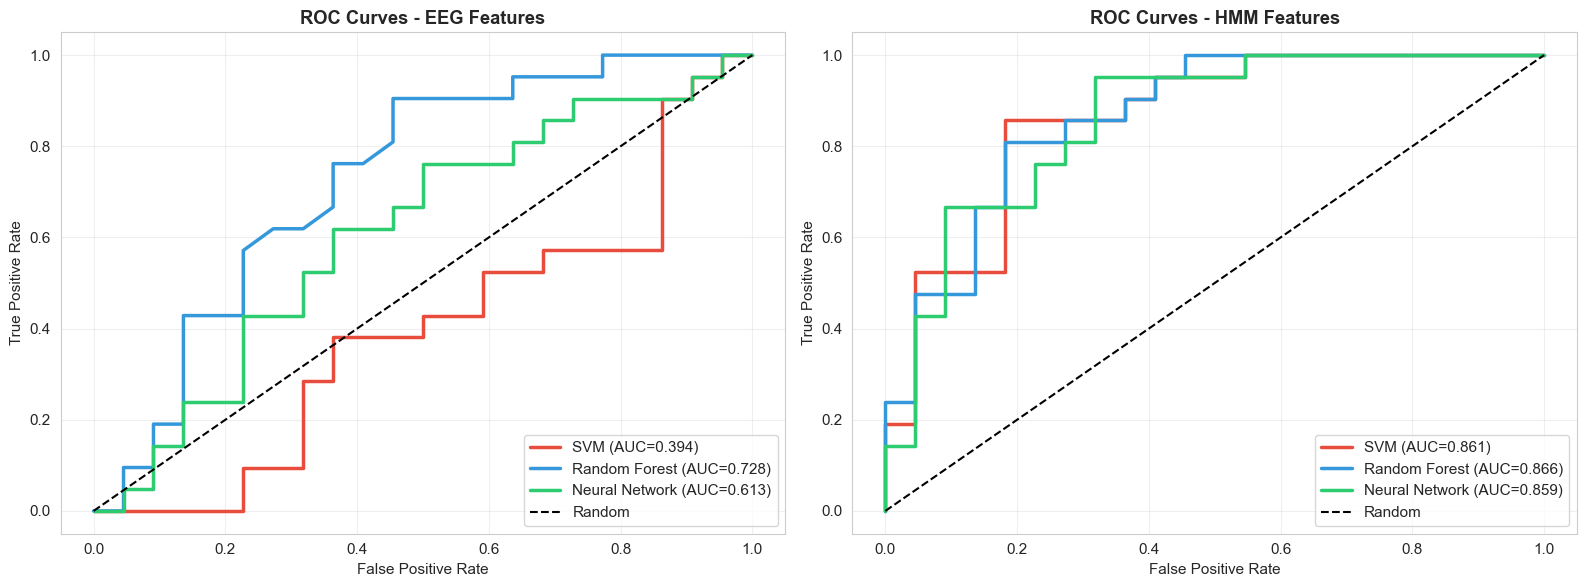

Saved: roc_curves.png


In [11]:
# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71']

for idx, (key, name, color) in enumerate(zip(model_keys, model_names, colors)):
    if results_eeg[key] is not None:
        y_test = results_eeg[key]['y_test']
        y_proba = results_eeg[key]['y_pred_proba']
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = results_eeg[key]['roc_auc']
        axes[0].plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC={auc_score:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves - EEG Features', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

for idx, (key, name, color) in enumerate(zip(model_keys, model_names, colors)):
    if results_hmm[key] is not None:
        y_test = results_hmm[key]['y_test']
        y_proba = results_hmm[key]['y_pred_proba']
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = results_hmm[key]['roc_auc']
        axes[1].plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC={auc_score:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves - HMM Features', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Saved: roc_curves.png")

## 9. Final Comparison and Analysis

In [12]:
print("\n" + "="*100)
print("COMPARATIVE ANALYSIS: EEG vs HMM Features")
print("="*100)

eeg_results_df = df_summary[df_summary['Feature'] == 'EEG']
hmm_results_df = df_summary[df_summary['Feature'] == 'HMM']

best_eeg = eeg_results_df.loc[eeg_results_df['Test_F1'].idxmax()]
best_hmm = hmm_results_df.loc[hmm_results_df['Test_F1'].idxmax()]

print("\nBest performing models:")
print(f"\nEEG Features:")
print(f"  Model:     {best_eeg['Model']}")
print(f"  F1 Score:  {best_eeg['Test_F1']:.4f}")
print(f"  ROC-AUC:   {best_eeg['Test_ROC_AUC']:.4f}")
print(f"  Accuracy:  {best_eeg['Test_Accuracy']:.4f}")

print(f"\nHMM Features:")
print(f"  Model:     {best_hmm['Model']}")
print(f"  F1 Score:  {best_hmm['Test_F1']:.4f}")
print(f"  ROC-AUC:   {best_hmm['Test_ROC_AUC']:.4f}")
print(f"  Accuracy:  {best_hmm['Test_Accuracy']:.4f}")

# Average performance
avg_eeg_f1 = eeg_results_df['Test_F1'].mean()
avg_hmm_f1 = hmm_results_df['Test_F1'].mean()

print(f"\nAverage F1 Score (across all models):")
print(f"  EEG: {avg_eeg_f1:.4f}")
print(f"  HMM: {avg_hmm_f1:.4f}")
print(f"  Difference: {abs(avg_hmm_f1 - avg_eeg_f1):.4f}")

# Conclusion
print("\n" + "="*100)
print("EXTRA CREDIT ANALYSIS: Value of HMM Timeseries Features")
print("="*100)

if avg_hmm_f1 > avg_eeg_f1:
    improvement = ((avg_hmm_f1 - avg_eeg_f1) / avg_eeg_f1) * 100
    print(f"\nConclusion: HMM timeseries features demonstrate superior performance.")
    print(f"Average F1 improvement: {improvement:.1f}%")
    print(f"\nInterpretation: Temporal dynamics captured by HMM state transitions")
    print(f"provide discriminative information beyond traditional frequency-domain features.")
else:
    print(f"\nConclusion: Traditional EEG features outperform HMM timeseries.")
    print(f"Static frequency-domain features are more informative for this task.")

print("\n" + "="*100)


COMPARATIVE ANALYSIS: EEG vs HMM Features

Best performing models:

EEG Features:
  Model:     SVM
  F1 Score:  0.6562
  ROC-AUC:   0.3939
  Accuracy:  0.4884

HMM Features:
  Model:     Neural Network
  F1 Score:  0.8163
  ROC-AUC:   0.8593
  Accuracy:  0.7907

Average F1 Score (across all models):
  EEG: 0.6135
  HMM: 0.7730
  Difference: 0.1595

EXTRA CREDIT ANALYSIS: Value of HMM Timeseries Features

Conclusion: HMM timeseries features demonstrate superior performance.
Average F1 improvement: 26.0%

Interpretation: Temporal dynamics captured by HMM state transitions
provide discriminative information beyond traditional frequency-domain features.

